In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

import dask

from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

# calculation
# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

# dask
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

Number of CPUs: 256, number of threads: 8, number of workers: 32


/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41951 instead
  warnings.warn(


2025-08-22 17:24:08,203 - distributed.nanny - WARNING - Restarting worker
2025-08-22 17:24:08,213 - distributed.nanny - WARNING - Restarting worker
2025-08-22 17:24:08,286 - distributed.nanny - WARNING - Restarting worker
2025-08-22 17:24:09,557 - distributed.nanny - WARNING - Restarting worker
2025-08-22 17:24:24,461 - distributed.nanny - WARNING - Restarting worker


In [2]:
def mask_cal(dset):
    ##This function calculate the land_sea mask according to the resolution of the data##
    ###negative values is ocean, positive values is land
    filemask = '/work/mh0731/from_Mistral/mh0731/m300876/land_sea_mask/GPM_IMERG_LandSeaMask.2.nc4'
    dsetmask = xr.open_dataset(filemask)
    lsmask01 = dsetmask.landseamask.where(
        dsetmask.landseamask<100).interp(lon=dset.lon.values,lat=dset.lat.values,method='linear') *0 +2
    lsmask01 = lsmask01.where(lsmask01==2,-2)
    return lsmask01

In [3]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

## Tmperature

_1. Load ERA data_

In [4]:
#Define a global pattern to find the files
glob_pattern_3d1 = 'era5_2020_' # 10km * 10km
## Define the paths
data_path1 = Path('/scratch/m/m300948/ERA5')
## Collect all file names with pathlib's rglob and list compression  
file_imerg = sorted([str(f) for f in data_path1.rglob(f'*{glob_pattern_3d1}*')])[:]

In [5]:
data_era = xr.open_mfdataset(
        file_imerg, combine='by_coords',engine='netcdf4',chunks=({'valid_time':20}))['t2m']

In [6]:
# flip the latitude
era5_flipped = data_era.isel(latitude=slice(None, None, -1))

In [7]:
# reset the longitude
# Fix longitude to range -180 to 180
era5_edit = era5_flipped.assign_coords(
    longitude=(((era5_flipped.longitude + 180) % 360) - 180)
)

# Then sort, so the values go from -180 → 180
era5_edit = era5_edit.sortby("longitude")

In [8]:
ABinterp_biome_era5 = AMZ_BD.interp(latitude=era5_edit.latitude, longitude=era5_edit.longitude)
era5_mult_amz = era5_edit.where(ABinterp_biome_era5==0, np.nan).sel(longitude=slice(-80,-40), latitude=slice(-20,10))

In [9]:
era5_mult_amz = era5_mult_amz.rename({'latitude': 'lat', 'longitude': 'lon'})

In [24]:
def contourf(data, vmin, vmax, space, cmap, extend, title):
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80,-40,-19,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    #m = data.sum('hour').plot(levels=np.linspace(0, 20, 10), extend='max', cmap='YlGnBu', transform=ccrs.PlateCarree())
    #m = ax.pcolormesh(lons,lats,data.sum('hour'),cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    m = ax.pcolormesh(lons,lats,data,cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    
     # Add contour line at values >= 10
    cs = ax.contour(
        lons,
        lats,
        data,
        levels=[10],                # draw the contour at value 10
        colors='red',               # choose color for the line
        linewidths=2.0,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(cs, fmt="%d", fontsize=15)  

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(vmin, vmax, space)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)
    plt.title(title, fontsize='20')
    plt.show()

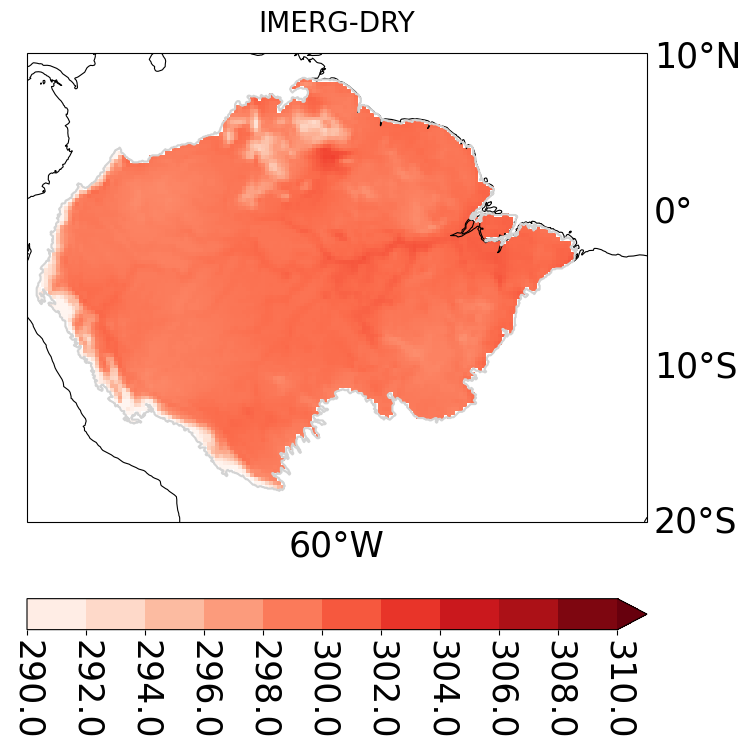

In [42]:
contourf(era5_mult_amz.mean(dim='valid_time'), 290, 310, 11, 'Reds', 'max','IMERG-DRY') # 23500-25500

_2. ICON_

In [12]:
tas_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/2mt/ctl_houly_tas_2022*',parallel=True)['tas']
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')

AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=tas_ctl.lat, longitude=tas_ctl.lon)

tas_ctl_mask = tas_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
tas_ctl_hour_mask = tas_ctl_mask.resample(time='H').mean()

Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb5e4f40>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb5bcea0>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ho

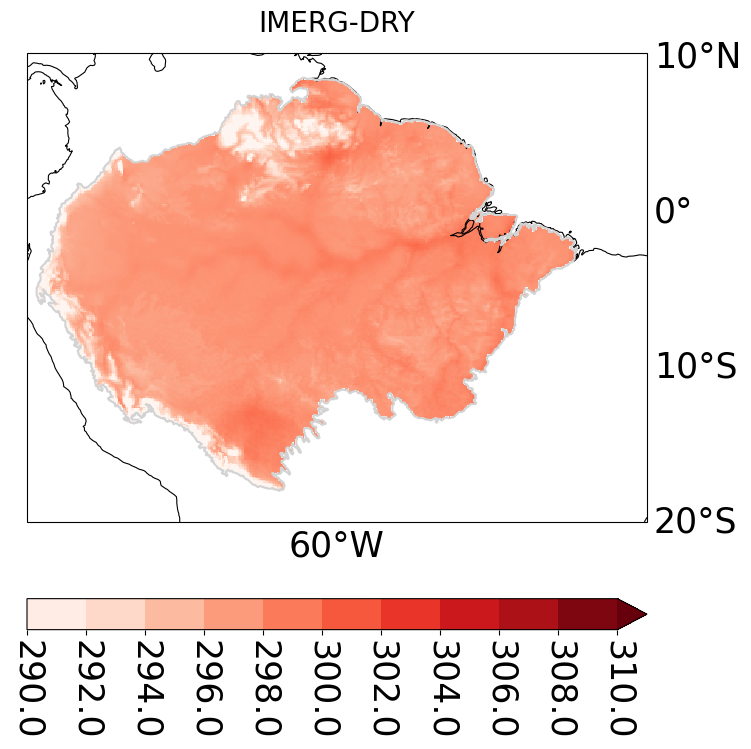

In [46]:
contourf(tas_ctl_hour_mask.sel(height_2=2).mean(dim='time'), 290, 310, 11, 'Reds', 'max','IMERG-DRY') # 23500-25500

In [21]:
tas_ctl_hour_mask_interp = tas_ctl_hour_mask.sel(height_2=2).interp(lat=era5_mult_amz.lat, lon=era5_mult_amz.lon)

In [23]:
a = tas_ctl_hour_mask_interp.mean(dim='time') - era5_mult_amz.mean(dim='valid_time')

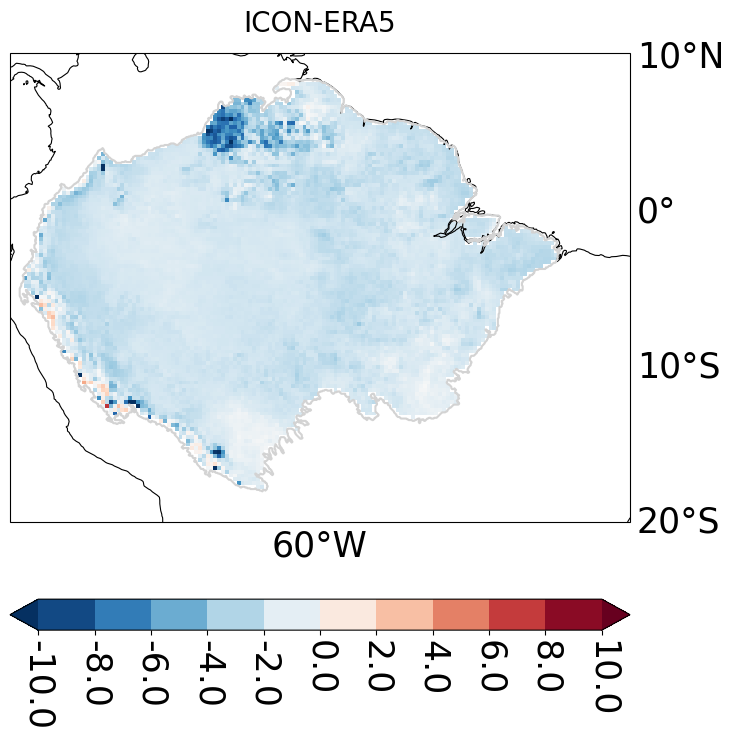

In [25]:
contourf(a, -10, 10, 11, 'RdBu_r', 'both','ICON-ERA5') # 23500-25500

In [41]:
tas_ctl_day_mask_interp = tas_ctl_hour_mask_interp.resample(time='D').mean()
tas_era5_day_amz = era5_mult_amz.resample(valid_time='D').mean()

In [42]:
tas_ctl_diff_interp = np.abs(tas_ctl_day_mask_interp.diff(dim="time")).sum(dim='time') 
tas_era5_diff_interp = np.abs(tas_era5_day_amz.diff(dim='valid_time')).sum(dim='valid_time') 

In [43]:
tas_ctl_diff_interp_range = tas_ctl_diff_interp.compute()

2025-08-21 22:33:23,567 - distributed.utils_perf - WARNING - full garbage collections took 13% CPU time recently (threshold: 10%)
2025-08-21 22:33:31,128 - distributed.utils_perf - WARNING - full garbage collections took 13% CPU time recently (threshold: 10%)


In [44]:
tas_era5_diff_interp_range = tas_era5_diff_interp.compute()

In [47]:
tas_era5_day_amz

<xarray.DataArray 't2m' (valid_time: 366, lat: 121, lon: 161)> Size: 29MB
dask.array<stack, shape=(366, 121, 161), dtype=float32, chunksize=(1, 78, 81), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 0
  * lat         (lat) float64 968B -20.0 -19.75 -19.5 -19.25 ... 9.5 9.75 10.0
  * lon         (lon) float64 1kB -80.0 -79.75 -79.5 ... -40.5 -40.25 -40.0
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

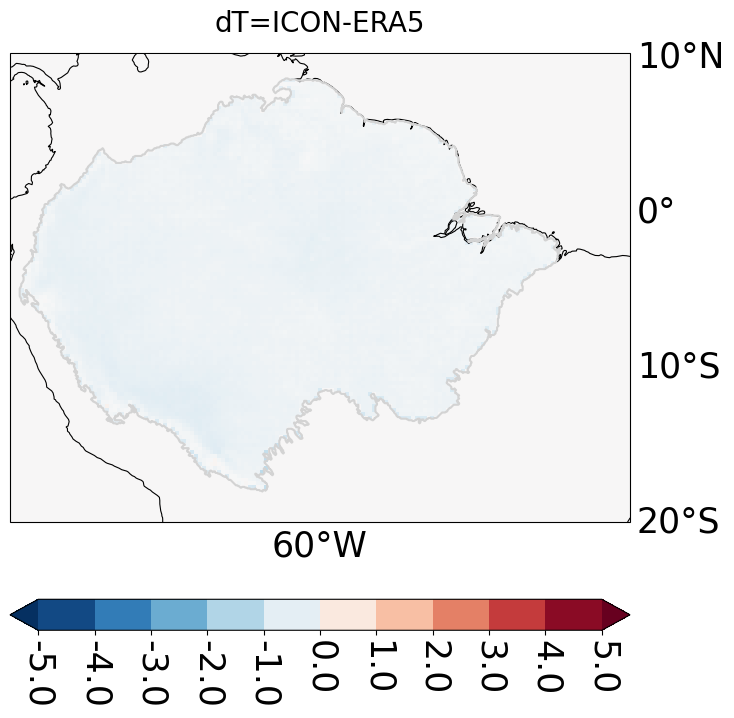

In [51]:
contourf(tas_ctl_diff_interp_range/(365-1)-tas_era5_diff_interp_range/(366-1), -5, 5, 11, 
         'RdBu_r', 'both','dT=ICON-ERA5') # 23500-25500

## Diurnal cycle

In [18]:
era_t2m_hourly = era5_mult_amz.mean(dim=('lat','lon')).groupby('valid_time.time').mean('valid_time',skipna=True).compute()

In [19]:
ctl_t2m_hourly = tas_ctl_hour_mask.isel(height_2=0).mean(dim=('lat','lon')).groupby('time.time').mean('time',skipna=True).compute()

Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb614b80>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

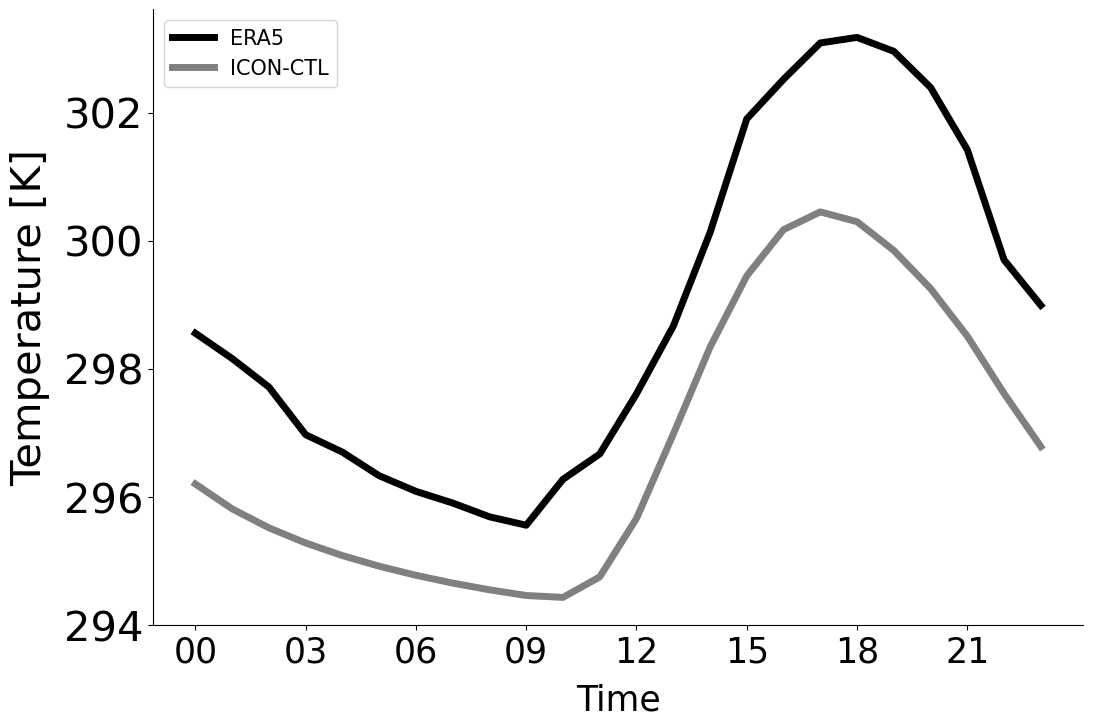

In [20]:
fig, ax = plt.subplots(figsize=(12,8))
# get color from BrBG
#shift = 3
#s_roll = br_t2m_hourly_mean.copy()
#s_roll.values[:] = np.roll(s_roll.values, shift) 

a = [0,3,6,9,12,15,18,21]
plt.plot(era_t2m_hourly, label='ERA5',c='black',linewidth=5)
plt.plot(ctl_t2m_hourly, label='ICON-CTL', c='grey',linewidth=5)
#plt.errorbar(a, s_roll.values[::3], br_t2m_std.sel(height_2=2).values[::3],  marker='o', markersize='8', linewidth=3, c='black')
#plt.errorbar(diurnal_ts_std_ngc2_mask['time'].dt.hour, tas_ctl_savg_diurnal[::3], std_diurnal_cycle.values, linestyle='', marker='o', markersize='8', linewidth=3, c='black')

#plt.errorbar(a, tas_ctl_diurnal[::3], std_diurnal_cycle, linestyle='', marker='o', markersize='8', linewidth=3, c='black')

plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')

ax.set_ylabel('Temperature [K]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Time',fontsize=25, labelpad = 10)
#plt.xlabel('Difference PR [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([0,3,6,9,12,15,18,21],['00','03','06','09','12','15','18','21'],fontsize=25,family='Arial')

ax.spines[['right', 'top']].set_visible(False)
plt.legend(fontsize=15)

## Max, Min

_1. Fluxnet_

In [18]:
era5_t2m_max = era5_mult_amz.resample(valid_time='1D').max(dim='valid_time') 

In [19]:
xarray_names = ['era5_t2m_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [20]:
era5_t2m_min = era5_mult_amz.resample(valid_time='1D').min(dim='valid_time') 

In [21]:
xarray_names = ['era5_t2m_min']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:621: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb64cfe0>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb628c20>
Traceback (m

In [23]:
xarray_names = ['era5_mult_amz']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

_2. ICON_

In [25]:
t2m_ctl_max = tas_ctl_hour_mask.isel(height_2=0).resample(time='1D').max(dim='time') 

In [26]:
xarray_names = ['t2m_ctl_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb654fe0>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask/array/reduction

In [27]:
t2m_ctl_min = tas_ctl_hour_mask.isel(height_2=0).resample(time='1D').min(dim='time') 

In [28]:
xarray_names = ['t2m_ctl_min']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb64cfe0>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb628c20>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ho

In [29]:
xarray_names = ['tas_ctl_hour_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.isel(height_2=0).values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

Exception ignored in: <function CachingFileManager.__del__ at 0x7fffcb64cfe0>
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


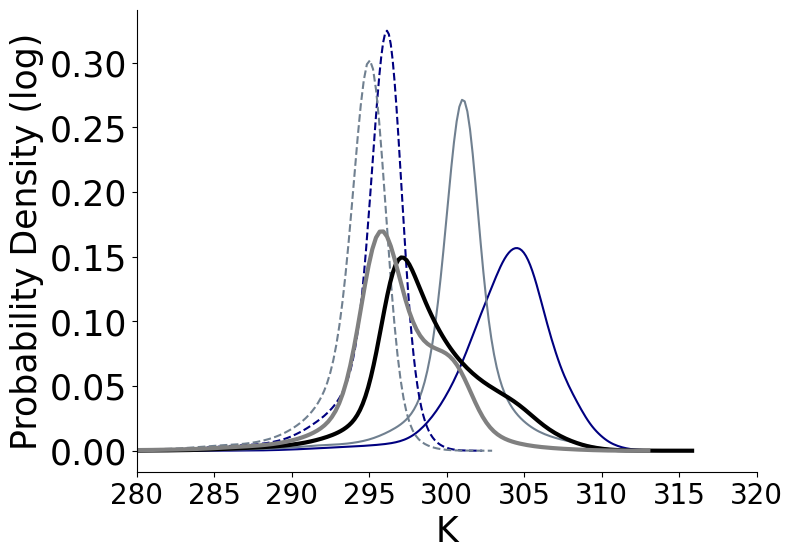

In [34]:
from scipy.ndimage import gaussian_filter1d

# Normalize the PDF
pdf_ctl_max, bins_ctl_max = np.histogram(era5_t2m_max_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_max, bins_def_max = np.histogram(t2m_ctl_max_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_min, bins_ctl_min = np.histogram(era5_t2m_min_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_min, bins_def_min = np.histogram(t2m_ctl_min_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_mean, bins_ctl_mean = np.histogram(era5_mult_amz_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_mean, bins_def_mean = np.histogram(tas_ctl_hour_mask_f, bins=250, density=True)  # Adjust the number of bins as needed

# Calculate the bin centers
bin_centers_ctl_max = (bins_ctl_max[:-1] + bins_ctl_max[1:]) * 0.5
bin_centers_def_max = (bins_def_max[:-1] + bins_def_max[1:]) * 0.5
bin_centers_ctl_min = (bins_ctl_min[:-1] + bins_ctl_min[1:]) * 0.5
bin_centers_def_min = (bins_def_min[:-1] + bins_def_min[1:]) * 0.5
bin_centers_ctl_mean = (bins_ctl_mean[:-1] + bins_ctl_mean[1:]) * 0.5
bin_centers_def_mean = (bins_def_mean[:-1] + bins_def_mean[1:]) * 0.5

# smooth
smooth_pdf_ctl_max = gaussian_filter1d(pdf_ctl_max, sigma=2.5)
smooth_pdf_def_max = gaussian_filter1d(pdf_def_max, sigma=2.5)
smooth_pdf_ctl_min = gaussian_filter1d(pdf_ctl_min, sigma=2.5)
smooth_pdf_def_min = gaussian_filter1d(pdf_def_min, sigma=2.5)
smooth_pdf_ctl_mean = gaussian_filter1d(pdf_ctl_mean, sigma=2.5)
smooth_pdf_def_mean = gaussian_filter1d(pdf_def_mean, sigma=2.5)

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl_max, smooth_pdf_ctl_max, label='CTL_max', color='navy', linewidth=1.5) # era
plt.plot(bin_centers_def_max, smooth_pdf_def_max, label='DEF_max', color='slategrey', linewidth=1.5) # icon
plt.plot(bin_centers_ctl_min, smooth_pdf_ctl_min, label='CTL_min', color='navy', linewidth=1.5, ls='--')
plt.plot(bin_centers_def_min, smooth_pdf_def_min, label='DEF_min', color='slategrey', linewidth=1.5, ls='--')
plt.plot(bin_centers_ctl_mean, smooth_pdf_ctl_mean, label='CTL_mean', color='black', linewidth=3)
plt.plot(bin_centers_def_mean, smooth_pdf_def_mean, label='DEF_,mean', color='grey', linewidth=3)

# Set labels and title
plt.xlabel('K', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=25)
#plt.xscale('log')
#
plt.xlim(280, 320)
# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()